# PSO for Perceptual Image Denoising — TV regularization
Given noisy image $v$, find $\hat{u}$ minimising:
$$\mathcal{L}_p(\hat{u}_p) = 1 - \text{SSIM}(\hat{u}_p, v_p) + \lambda \cdot \text{TV}(\hat{u}_p), \quad \hat{u}_k \in [0,1]$$
- $\hat{u}_p$ — denoised patch (optimization variable), $v_p$ — corresponding noisy patch (fixed)
- $\lambda$ — regularization weight balancing SSIM and TV terms
- $\hat{u}_k$ — pixel $k$ of the denoised image, constrained to valid intensity range

Strategy: split into patches, optimise each independently in parallel, stitch back.

In [16]:
# libraries
import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim
from skimage import util
from PIL import Image
import pyswarms
import time
import multiprocess as multiprocessing

In [17]:
# parameters
patch_shape = (16, 16)

n_particles = 20
n_iter = 200
init_noise = 0.1

tv_lambda = 0.1
w_inertia = 0.7
c1_cognitive = 1.5
c2_social = 1.5

### 1 — Preprocessing

In [18]:
# load, convert to grayscale, normalize to [0, 1]
with Image.open("slice_noisy.png") as im:
    im_grey = im.convert("L")
print(f"Image format, size, color mode: {im_grey.format, im_grey.size, im_grey.mode}")
im_n = np.array(im_grey) / 255

# pad to nearest multiple of patch_shape if needed
h, w = im_n.shape
h_pad = int(np.ceil(h / patch_shape[0])) * patch_shape[0]
w_pad = int(np.ceil(w / patch_shape[1])) * patch_shape[1]
pad_h = h_pad - h
pad_w = w_pad - w

if pad_h > 0 or pad_w > 0:
    im_n = np.pad(im_n, ((0, pad_h), (0, pad_w)), mode="reflect")
    print(f"Padded from ({h}, {w}) → {im_n.shape}")
else:
    print(f"Image shape: {im_n.shape} — no padding needed")

Image format, size, color mode: (None, (301, 512), 'L')
Padded from (512, 301) → (512, 304)


Shape of patched image: (32, 19, 16, 16)
Patch shape: (16, 16)


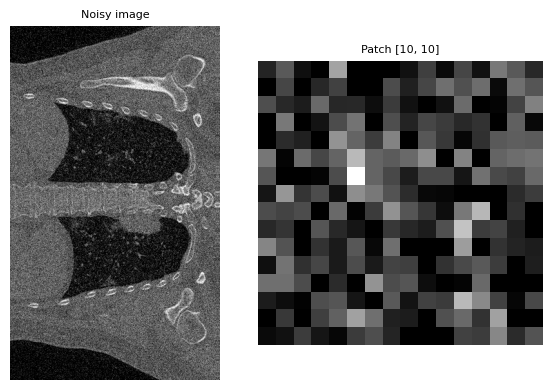

In [19]:
# divide image into patches
patches_im_n = util.view_as_blocks(im_n, patch_shape)
print(f"Shape of patched image: {patches_im_n.shape}")

# select a patch for workflow development
v_patch = patches_im_n[10, 10]
print(f"Patch shape: {v_patch.shape}")

# visualize image and selected patch
fig, axes = plt.subplots(1, 2, figsize=(6, 4))
axes[0].imshow(im_n, cmap="gray")
axes[0].set_title("Noisy image", fontsize=8)
axes[0].axis("off")

axes[1].imshow(v_patch, cmap="gray")
axes[1].set_title("Patch [10, 10]", fontsize=8)
axes[1].axis("off")

plt.tight_layout()
plt.show()

### 1.2 — Total variation (TV) and objective function
$$\text{TV}(\hat{u}) = \sum_{i,j} \sqrt{(\hat{u}_{i+1,j} - \hat{u}_{i,j})^2 + (\hat{u}_{i,j+1} - \hat{u}_{i,j})^2}$$
- $(i,j)$ — pixel row and column indices; the sum penalizes large differences between neighbouring pixels

$$\mathcal{L}_p(\hat{u}_p) = 1 - \text{SSIM}(\hat{u}_p, v_p) + \lambda \cdot \text{TV}(\hat{u}_p), \quad \hat{u}_k \in [0,1]$$
- $\text{SSIM} \in [-1, 1]$ — structural similarity; $1 - \text{SSIM}$ is 0 when patches are identical
- $\lambda \cdot \text{TV}$ — smoothness penalty; higher $\lambda$ pushes the result towards flatter patches

In [20]:
# compute difference between each pixel and its right resp. bottom neighbour,
# drop last column resp. row to address shape differences, then compute TV
def tv(u_patch):
    diff_down = u_patch[1:, :-1] - u_patch[:-1, :-1]
    diff_right = u_patch[:-1, 1:] - u_patch[:-1, :-1]
    return np.sum(np.sqrt(diff_down**2 + diff_right**2))

def objective(u_patch, v_patch):
    ssim_patch = ssim(u_patch, v_patch, data_range = 1.0, full=False, gradient=False)
    return 1.0 - float(ssim_patch) + tv_lambda*tv(u_patch)

In [21]:
# check: (0 - 0) + tv_lambda * tv(v_patch)
tv(v_patch)
objective(v_patch, v_patch)

np.float64(3.2883497296901556)

### 2 — PSO (manual)
$$v_i^{t+1} = w \cdot v_i^t + c_1 r_1 (p_i - x_i^t) + c_2 r_2 (g - x_i^t)$$
$$x_i^{t+1} = x_i^t + v_i^{t+1}$$
- $x_i^t$ — position of particle $i$ at iteration $t$ (a candidate denoised patch, flattened to 256 values)
- $v_i^t$ — velocity of particle $i$ (how much each pixel value changes per step)
- $w$ — inertia weight: how much of the previous velocity is kept
- $c_1, c_2$ — cognitive and social weights: pull towards personal and global best
- $r_1, r_2$ — random scalars drawn from $\mathcal{U}(0,1)$ each iteration (stochasticity)
- $p_i$ — personal best: lowest-loss position particle $i$ has ever visited
- $g$ — global best: lowest-loss position any particle has ever visited

#### Particle swarm optimization loop
Each iteration, for particle i:
1. Update velocity using w, c1, c2, p[i], g
2. Update position
3. Clip positions to [0,1] pixel range
4. Compute new loss → new_score
5. If new_score < p_scores[i]: update p[i] = new position, p_scores[i] = new_score
6. If new_score < g_score: update g = new position, g_score = new_score

In [22]:
def initialize_swarm(v_patch):
    v_patch_flat = v_patch.flatten()
    # initialize particles near the noisy patch with small perturbations for better convergence
    u_particles = v_patch_flat + np.random.uniform(-init_noise, init_noise, size=(n_particles, v_patch_flat.size))
    u_particles = np.clip(u_particles, 0, 1)
    u_velocity = np.random.uniform(-0.1, 0.1, size = (n_particles, v_patch_flat.size))

    u_patches = u_particles.reshape(n_particles, *patch_shape)
    scores = np.array([objective(u_patch, v_patch) for u_patch in u_patches], dtype = float)

    u_best_p = u_particles.copy()
    u_best_scores = scores.copy()
    g_best_p = u_best_p[np.argmin(u_best_scores)]
    g_best_scores = np.min(u_best_scores)

    return u_particles, u_velocity, u_best_p, u_best_scores, g_best_p, g_best_scores

In [23]:
# no random seed, as PSO stochastic by design
# clamp velocity to [-0.1, 0.1] to prevent particles overshooting the [0,1] pixel range
# clip positions to [0, 1] pixel range

def pso_loop(v_patch, u_particles, u_velocity, u_best_p, u_best_scores, g_best_p, g_best_scores):
    for n in range(0, n_iter):
        r1 = np.random.uniform(size = (n_particles, v_patch.flatten().size))
        r2 = np.random.uniform(size = (n_particles, v_patch.flatten().size))

        u_velocity = w_inertia*u_velocity + c1_cognitive*r1*(u_best_p - u_particles) + c2_social*r2*(g_best_p - u_particles)
        u_velocity = np.clip(u_velocity, -0.1, 0.1)

        u_particles = u_particles + u_velocity
        u_particles = np.clip(u_particles, 0, 1)

        u_patches = u_particles.reshape(n_particles, *patch_shape)
        new_scores = np.array([objective(u_patch, v_patch) for u_patch in u_patches], dtype = float)

        improved = new_scores < u_best_scores
        u_best_scores[improved] = new_scores[improved]
        u_best_p[improved] = u_particles[improved]

        if new_scores.min() < g_best_scores:
            g_best_scores = new_scores.min()
            g_best_p = u_best_p[np.argmin(new_scores)]

    return g_best_scores, g_best_p


def denoise_patch_manual(v_patch):
    u_particles, u_velocity, u_best_p, u_best_scores, g_best_p, g_best_scores = initialize_swarm(v_patch)
    g_best_scores, g_best_p = pso_loop(v_patch, u_particles, u_velocity, u_best_p, u_best_scores, g_best_p, g_best_scores)
    return g_best_p.reshape(patch_shape)

### 3 — PSO: pyswarms
Same patch, same hyperparameters.

In [24]:
def denoise_patch_pyswarms(v_patch):
    v_patch_flat = v_patch.flatten()
    # initialize particles near the noisy patch with small perturbations for better convergence
    init_pos = v_patch_flat + np.random.uniform(-init_noise, init_noise, size=(n_particles, v_patch_flat.size))
    init_pos = np.clip(init_pos, 0, 1)

    def wrapper(swarm):
        return np.array([objective(swarm[s].reshape(patch_shape), v_patch) for s in range(len(swarm))])

    bounds = (np.zeros(v_patch_flat.size), np.ones(v_patch_flat.size))
    swarm_options = {"c1": c1_cognitive, "c2": c2_social, "w": w_inertia}
    optimizer = pyswarms.single.GlobalBestPSO(n_particles, dimensions=v_patch_flat.size, options=swarm_options, bounds=bounds, velocity_clamp=(-0.1, 0.1), init_pos=init_pos)
    best_cost, best_pos = optimizer.optimize(wrapper, iters=n_iter, verbose=False)

    return best_pos.reshape(patch_shape)

### 4 — Full Image Pipeline

#### 4.1 — Manual implementation

In [25]:
# batch process image patches
# stitch patches back: list → (n_patches, 16, 16) → (n_rows, n_cols, 16, 16) →
# transpose to (n_rows, 16, n_cols, 16) so pixels of the same row are adjacent → full image

def denoise_image_manual(im_n):
    patches_im_n = util.view_as_blocks(im_n, patch_shape)
    v_patches = patches_im_n.reshape(-1, *patch_shape)

    with multiprocessing.Pool() as pool:
        denoised_patches = pool.map(denoise_patch_manual, v_patches)

    denoised_patches_arr = np.array(denoised_patches)
    n_rows = im_n.shape[0] // patch_shape[0]
    n_cols = im_n.shape[1] // patch_shape[1]
    den_reshaped = denoised_patches_arr.reshape(n_rows, n_cols, patch_shape[0], patch_shape[1])
    den_final = den_reshaped.transpose(0, 2, 1, 3).reshape(im_n.shape)
    return den_final

In [26]:
t0 = time.time()
denoised_manual = denoise_image_manual(im_n)
t_manual = time.time() - t0
print(f"Manual PSO: {t_manual:.1f} s")

Manual PSO: 14.8 s


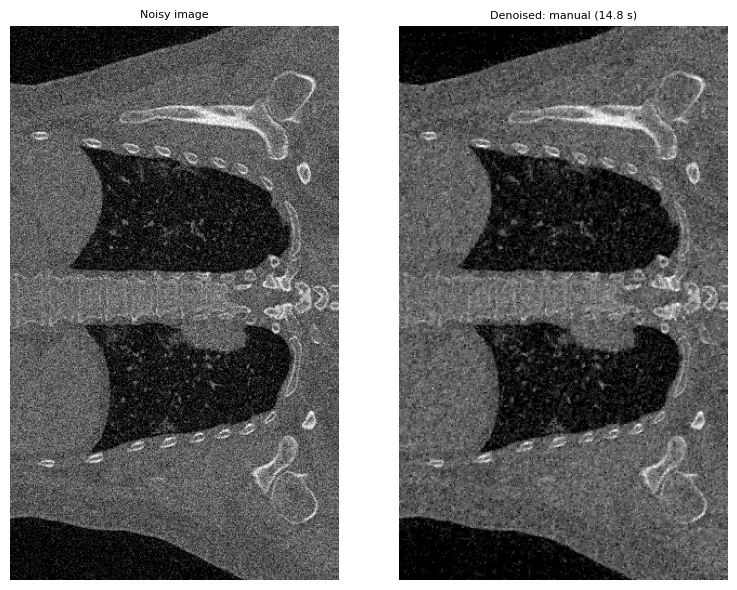

In [27]:
# visualize
fig, axes = plt.subplots(1, 2, figsize=(8, 6))
axes[0].imshow(im_n, cmap="gray")
axes[0].set_title("Noisy image", fontsize=8)
axes[0].axis("off")

axes[1].imshow(denoised_manual, cmap="gray")
axes[1].set_title(f"Denoised: manual ({t_manual:.1f} s)", fontsize=8)
axes[1].axis("off")

plt.tight_layout()
plt.show()

#### 4.2 — pyswarms implementation

In [28]:
def denoise_image_pyswarms(im_n):
    patches_im_n = util.view_as_blocks(im_n, patch_shape)
    v_patches = patches_im_n.reshape(-1, *patch_shape)

    with multiprocessing.Pool() as pool:
        denoised_patches = pool.map(denoise_patch_pyswarms, v_patches)

    denoised_patches_arr = np.array(denoised_patches)
    n_rows = im_n.shape[0] // patch_shape[0]
    n_cols = im_n.shape[1] // patch_shape[1]
    den_reshaped = denoised_patches_arr.reshape(n_rows, n_cols, patch_shape[0], patch_shape[1])
    den_final = den_reshaped.transpose(0, 2, 1, 3).reshape(im_n.shape)
    return den_final

In [29]:
t0 = time.time()
denoised_psw = denoise_image_pyswarms(im_n)
t_psw = time.time() - t0
print(f"pyswarms PSO: {t_psw:.1f} s")

pyswarms PSO: 16.1 s


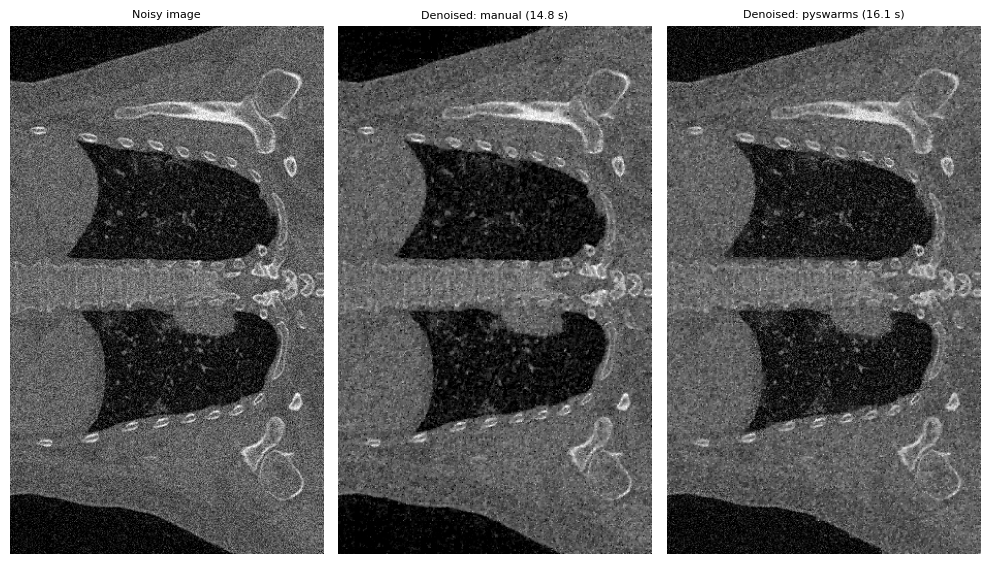

In [36]:
# visualize
fig, axes = plt.subplots(1, 3, figsize=(10, 6))
axes[0].imshow(im_n, cmap="gray")
axes[0].set_title("Noisy image", fontsize=8)
axes[0].axis("off")

axes[1].imshow(denoised_manual, cmap="gray")
axes[1].set_title(f"Denoised: manual ({t_manual:.1f} s)", fontsize=8)
axes[1].axis("off")

axes[2].imshow(denoised_psw, cmap="gray")
axes[2].set_title(f"Denoised: pyswarms ({t_psw:.1f} s)", fontsize=8)
axes[2].axis("off")

plt.tight_layout()
plt.show()

### 5 — Quantitative metrics

In [31]:
def tv_full(img):
    diff_down = img[1:, :-1] - img[:-1, :-1]
    diff_right = img[:-1, 1:] - img[:-1, :-1]
    return np.sum(np.sqrt(diff_down**2 + diff_right**2))

def objective_full(u, v):
    patches_u = util.view_as_blocks(u, patch_shape).reshape(-1, *patch_shape)
    patches_v = util.view_as_blocks(v, patch_shape).reshape(-1, *patch_shape)
    ssim_pooled = np.mean([ssim(pu, pv, data_range=1.0) for pu, pv in zip(patches_u, patches_v)])
    return 1.0 - ssim_pooled + tv_lambda*tv_full(u)

images = {
    "Noisy":        im_n,
    "Manual PSO":   denoised_manual,
    "pyswarms PSO": denoised_psw,
}

print(f"{'Image':<18} {'Mean':>6} {'Std':>6} {'TV':>10} {'SSIM vs noisy':>14} {'Objective L':>12}")
print("-" * 70)
for name, img in images.items():
    mean_val = img.mean()
    std_val = img.std()
    tv_val = tv_full(img)
    ssim_vs_n = ssim(img, im_n, data_range=1.0) if name != "Noisy" else 1.0
    obj_val = objective_full(img, im_n)
    print(f"{name:<18} {mean_val:>6.4f} {std_val:>6.4f} {tv_val:>10.1f} {ssim_vs_n:>14.4f} {obj_val:>12.4f}")

Image                Mean    Std         TV  SSIM vs noisy  Objective L
----------------------------------------------------------------------
Noisy              0.2992 0.1821    25566.3         1.0000    2556.6253
Manual PSO         0.2925 0.1792    15820.8         0.6520    1582.4019
pyswarms PSO       0.3028 0.1695    18962.5         0.7119    1896.5247


### 6 — Lambda
Manual PSO only (faster), vary tv_lambda, all other params fixed.

tv_lambda=0.01 done in 13.7 s
tv_lambda=0.05 done in 14.8 s
tv_lambda=0.1 done in 14.9 s
tv_lambda=0.3 done in 15.1 s

 tv_lambda         TV  SSIM vs noisy  Objective L  Time (s)
------------------------------------------------------------
      0.01    20885.8         0.8947     208.9261      13.7
      0.05    16705.5         0.7329     835.5006      14.8
      0.10    15953.2         0.6582    1595.6351      14.9
      0.30    15391.6         0.5766    4617.9069      15.1


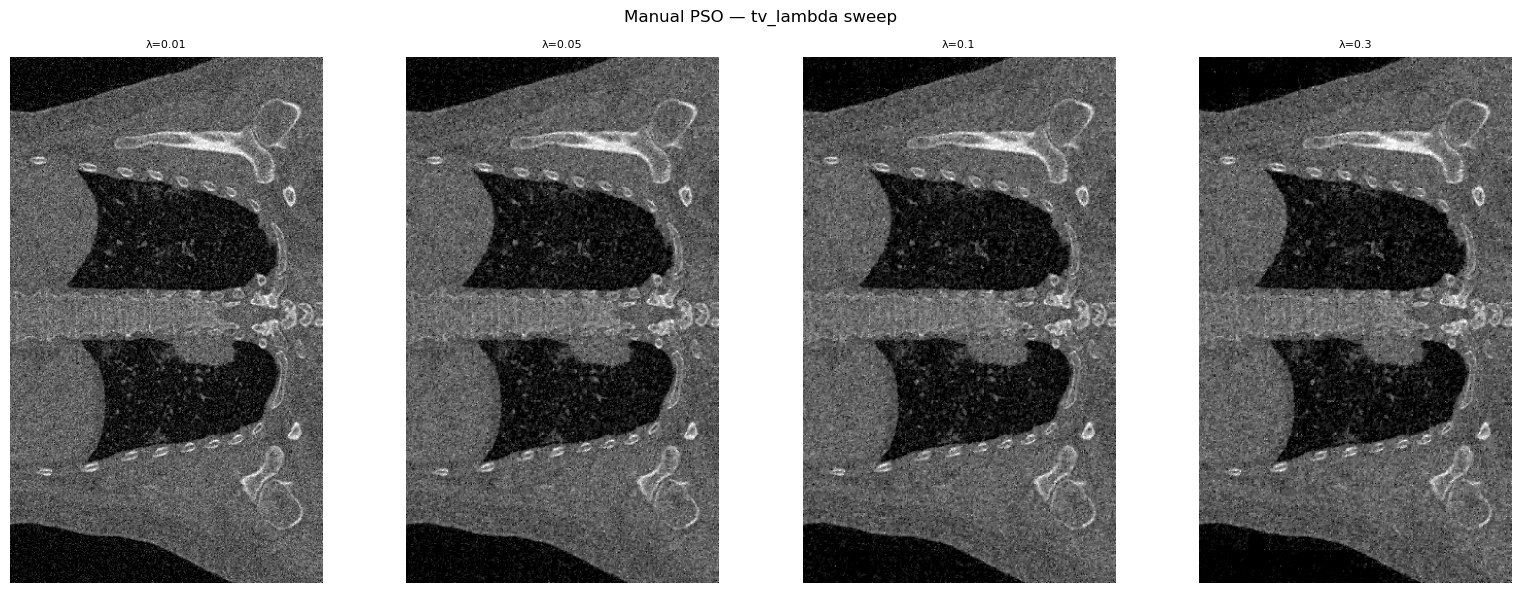

In [37]:
lambda_values = [0.01, 0.05, 0.1, 0.3]
results_lambda = {}

for lam in lambda_values:
    tv_lambda = lam
    t0 = time.time()
    den = denoise_image_manual(im_n)
    elapsed = time.time() - t0
    results_lambda[lam] = {"img": den, "time": elapsed}
    print(f"tv_lambda={lam} done in {elapsed:.1f} s")

tv_lambda = 0.1  # reset to default

# metrics table
print(f"\n{'tv_lambda':>10} {'TV':>10} {'SSIM vs noisy':>14} {'Objective L':>12} {'Time (s)':>9}")
print("-" * 60)
for lam, r in results_lambda.items():
    img = r["img"]
    tv_val = tv_full(img)
    ssim_val = ssim(img, im_n, data_range=1.0)
    # recompute objective with the lambda used for that run
    patches_u = util.view_as_blocks(img, patch_shape).reshape(-1, *patch_shape)
    patches_v = util.view_as_blocks(im_n, patch_shape).reshape(-1, *patch_shape)
    ssim_pooled = np.mean([ssim(pu, pv, data_range=1.0) for pu, pv in zip(patches_u, patches_v)])
    obj = 1.0 - ssim_pooled + lam*tv_val
    print(f"{lam:>10.2f} {tv_val:>10.1f} {ssim_val:>14.4f} {obj:>12.4f} {r['time']:>9.1f}")

# visual comparison
fig, axes = plt.subplots(1, len(lambda_values), figsize=(4*len(lambda_values), 6))
for ax, (lam, r) in zip(axes, results_lambda.items()):
    ax.imshow(r["img"], cmap="gray")
    ax.set_title(f"λ={lam}", fontsize=8)
    ax.axis("off")
plt.suptitle("Manual PSO — tv_lambda sweep")
plt.tight_layout()
plt.show()

### 7 — Single-patch convergence
Compare n_iter = 200, 500, 1000 on the center patch.

n_iter= 200  final L=2.582578
n_iter= 500  final L=2.491978
n_iter=1000  final L=1.872192


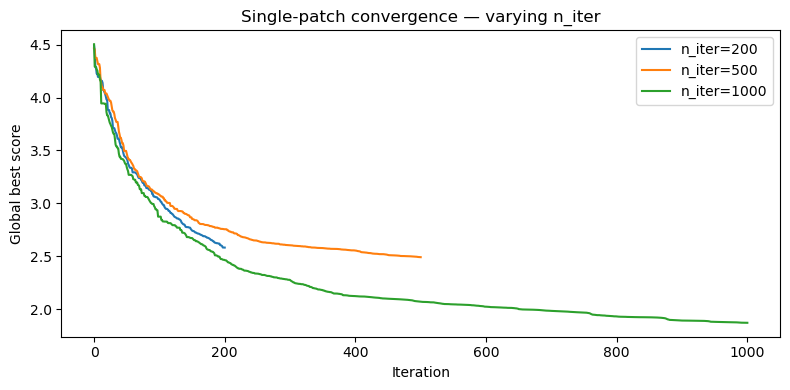

In [33]:
tv_lambda = 0.1  # fixed for this experiment
cx, cy = im_n.shape[0] // 2, im_n.shape[1] // 2
v_patch_test = im_n[cx:cx + patch_shape[0], cy:cy + patch_shape[1]]


def pso_with_history(v_patch, n_iterations):
    u_particles, u_velocity, u_best_p, u_best_scores, g_best_p, g_best_scores = initialize_swarm(v_patch)
    history = [g_best_scores]
    for n in range(0, n_iterations):
        r1 = np.random.uniform(size = (n_particles, v_patch.flatten().size))
        r2 = np.random.uniform(size = (n_particles, v_patch.flatten().size))
        u_velocity = w_inertia*u_velocity + c1_cognitive*r1*(u_best_p - u_particles) + c2_social*r2*(g_best_p - u_particles)
        u_velocity = np.clip(u_velocity, -0.1, 0.1)
        u_particles = u_particles + u_velocity
        u_particles = np.clip(u_particles, 0, 1)
        u_patches = u_particles.reshape(n_particles, *patch_shape)
        new_scores = np.array([objective(up, v_patch) for up in u_patches], dtype = float)
        improved = new_scores < u_best_scores
        u_best_scores[improved] = new_scores[improved]
        u_best_p[improved] = u_particles[improved]
        if new_scores.min() < g_best_scores:
            g_best_scores = new_scores.min()
            g_best_p = u_best_p[np.argmin(new_scores)]
        history.append(g_best_scores)
    return np.array(history), g_best_p.reshape(patch_shape)


iter_counts = [200, 500, 1000]
histories = {}
for n in iter_counts:
    hist, best_patch = pso_with_history(v_patch_test, n)
    histories[n] = hist
    print(f"n_iter={n:4d}  final L={hist[-1]:.6f}")

plt.figure(figsize=(8, 4))
for n, hist in histories.items():
    plt.plot(hist, label=f"n_iter={n}")
plt.xlabel("Iteration")
plt.ylabel("Global best score")
plt.title("Single-patch convergence — varying n_iter")
plt.legend()
plt.tight_layout()
plt.show()

### 8 — Full image with n_iter=1000

In [34]:
n_iter = 1000
tv_lambda = 0.1

t0 = time.time()
denoised_1000 = denoise_image_manual(im_n)
t_1000 = time.time() - t0
print(f"Manual PSO n_iter=1000: {t_1000:.1f} s")

# metrics vs n_iter=200
print(f"\n{'n_iter':>8} {'TV':>10} {'SSIM vs noisy':>14} {'Objective L':>12}")
print("-" * 48)
for label, img in [("200", denoised_manual), ("1000", denoised_1000)]:
    tv_val = tv_full(img)
    ssim_val = ssim(img, im_n, data_range=1.0)
    obj_val = objective_full(img, im_n)
    print(f"{label:>8} {tv_val:>10.1f} {ssim_val:>14.4f} {obj_val:>12.4f}")

n_iter = 200  # reset

Manual PSO n_iter=1000: 86.9 s

  n_iter         TV  SSIM vs noisy  Objective L
------------------------------------------------
     200    15820.8         0.6520    1582.4019
    1000    12116.7         0.5667    1212.0654


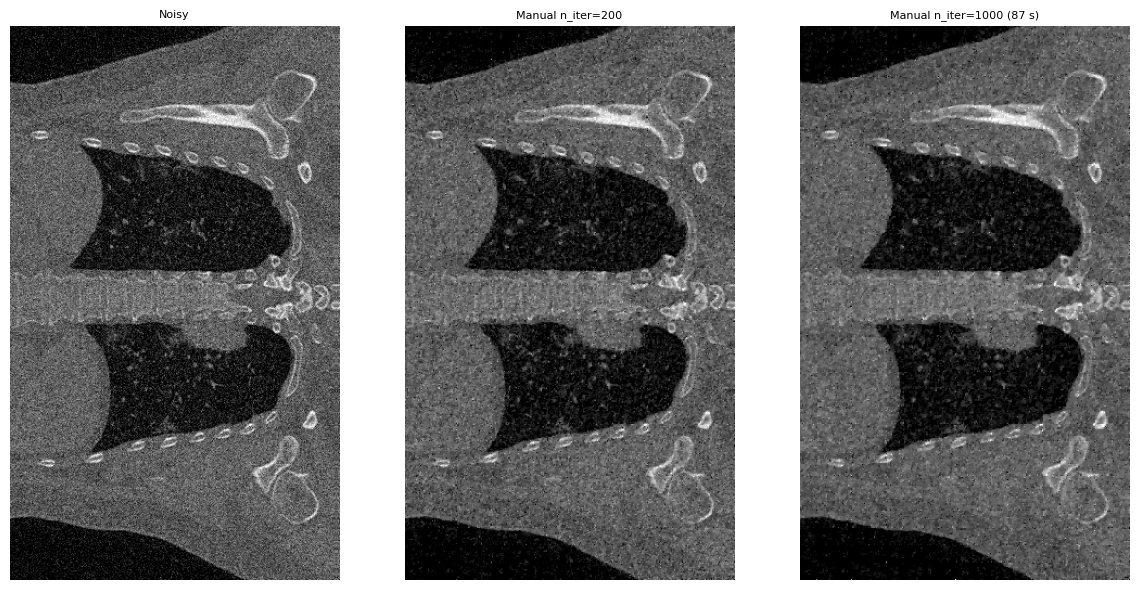

In [38]:
# visualize
fig, axes = plt.subplots(1, 3, figsize=(12, 6))
axes[0].imshow(im_n, cmap="gray")
axes[0].set_title("Noisy", fontsize=8)
axes[0].axis("off")

axes[1].imshow(denoised_manual, cmap="gray")
axes[1].set_title("Manual n_iter=200", fontsize=8)
axes[1].axis("off")

axes[2].imshow(denoised_1000, cmap="gray")
axes[2].set_title(f"Manual n_iter=1000 ({t_1000:.0f} s)", fontsize=8)
axes[2].axis("off")

plt.tight_layout()
plt.show()